# NII Scenario Tool — Major European G-SIB ALM Model
**Institution:** Major European G-SIB (Anonymised) | **Currency:** EUR millions | **Base Year:** 2025A

This notebook simulates Net Interest Income (NII) under four interest rate scenarios using a static 2025A balance sheet. The tool applies rate shocks to each asset and liability item according to its repricing behaviour (floating, partial beta, or fixed), and outputs an NII comparison table and chart.

**Scenarios:** Base (0bp) | Rate Hike (+200bp) | Rate Cut (−200bp) | Stress (+300bp)

In [1]:
# --- Libraries ---
import pandas as pd          # for building tables
import matplotlib.pyplot as plt  # for charts
import matplotlib.ticker as mtick # for formatting numbers on chart

In [2]:
# --- Cell 3: Balance Sheet Data (2025A) ---
# Source: Major European G-SIB 2025A actuals | EUR millions

# ASSETS
# Each asset has: name, balance (€m), base rate, repricing factor
assets = pd.DataFrame([
    {"item": "Cash & CB reserves",   "balance": 211330, "base_rate": 0.0250, "reprice_factor": 1.0},
    {"item": "Loans to customers",   "balance": 897358, "base_rate": 0.0380, "reprice_factor": 0.9},
    {"item": "Interbank loans",      "balance":  26259, "base_rate": 0.0310, "reprice_factor": 1.0},
    {"item": "Securities portfolio", "balance": 153107, "base_rate": 0.0300, "reprice_factor": 0.0},
])

# LIABILITIES
# uses_deposit_beta = True means repricing factor comes from the scenario, not fixed here
liabilities = pd.DataFrame([
    {"item": "Customer deposits",  "balance": 1075564, "base_rate": 0.0050, "reprice_factor": None, "uses_deposit_beta": True},
    {"item": "Interbank funding",  "balance":   69938, "base_rate": 0.0310, "reprice_factor": 1.0,  "uses_deposit_beta": False},
    {"item": "Repo funding",       "balance":  357947, "base_rate": 0.02415,"reprice_factor": 1.0,  "uses_deposit_beta": False},
    {"item": "Bonds issued",       "balance":  173933, "base_rate": 0.0325, "reprice_factor": 0.0,  "uses_deposit_beta": False},
    {"item": "Subordinated debt",  "balance":   34468, "base_rate": 0.0250, "reprice_factor": 0.0,  "uses_deposit_beta": False},
])

# Quick check — print both tables
print("ASSETS:")
print(assets.to_string(index=False))
print("\nLIABILITIES:")
print(liabilities.to_string(index=False))

ASSETS:
                item  balance  base_rate  reprice_factor
  Cash & CB reserves   211330      0.025             1.0
  Loans to customers   897358      0.038             0.9
     Interbank loans    26259      0.031             1.0
Securities portfolio   153107      0.030             0.0

LIABILITIES:
             item  balance  base_rate  reprice_factor  uses_deposit_beta
Customer deposits  1075564    0.00500             NaN               True
Interbank funding    69938    0.03100             1.0              False
     Repo funding   357947    0.02415             1.0              False
     Bonds issued   173933    0.03250             0.0              False
Subordinated debt    34468    0.02500             0.0              False


In [3]:
# --- Cell 4: Scenario Definitions ---
# Source: Major European G-SIB ALM Engine — Section A1
# Rate shock is added on top of each item's base rate (subject to repricing factor)

scenarios = [
    {"name": "Base",      "rate_shock": 0.00,  "deposit_beta": 0.40},
    {"name": "Rate Hike", "rate_shock": 0.02,  "deposit_beta": 0.50},
    {"name": "Rate Cut",  "rate_shock": -0.02, "deposit_beta": 0.30},
    {"name": "Stress",    "rate_shock": 0.03,  "deposit_beta": 0.60},
]

# Quick check — print the scenarios
print("SCENARIOS:")
for s in scenarios:
    shock_bp = int(s["rate_shock"] * 10000)  # convert to basis points for display
    print(f"  {s['name']:<12} | Shock: {shock_bp:>+5}bp | Deposit Beta: {s['deposit_beta']}")

SCENARIOS:
  Base         | Shock:    +0bp | Deposit Beta: 0.4
  Rate Hike    | Shock:  +200bp | Deposit Beta: 0.5
  Rate Cut     | Shock:  -200bp | Deposit Beta: 0.3
  Stress       | Shock:  +300bp | Deposit Beta: 0.6


In [4]:
# --- Cell 5: NII Calculation Function ---

def calculate_nii(assets, liabilities, scenario):
    """
    Given a balance sheet (assets + liabilities) and a rate scenario,
    calculate NII = Total Interest Income - Total Interest Expense.
    Returns a dict with the full breakdown.
    """
    shock = scenario["rate_shock"]
    beta  = scenario["deposit_beta"]

    # --- ASSETS ---
    asset_rows = []
    for _, row in assets.iterrows():
        new_rate = row["base_rate"] + (shock * row["reprice_factor"])
        interest = row["balance"] * new_rate
        asset_rows.append({
            "item":     row["item"],
            "balance":  row["balance"],
            "new_rate": new_rate,
            "interest": interest
        })
    asset_df = pd.DataFrame(asset_rows)
    total_income = asset_df["interest"].sum()

    # --- LIABILITIES ---
    liab_rows = []
    for _, row in liabilities.iterrows():
        # deposits use deposit beta; all others use their fixed reprice factor
        if row["uses_deposit_beta"]:
            new_rate = row["base_rate"] + (shock * beta)
        else:
            new_rate = row["base_rate"] + (shock * row["reprice_factor"])
        interest = row["balance"] * new_rate
        liab_rows.append({
            "item":     row["item"],
            "balance":  row["balance"],
            "new_rate": new_rate,
            "interest": interest
        })
    liab_df = pd.DataFrame(liab_rows)
    total_expense = liab_df["interest"].sum()

    # --- NII ---
    nii = total_income - total_expense

    return {
        "scenario":      scenario["name"],
        "total_income":  total_income,
        "total_expense": total_expense,
        "nii":           nii,
        "asset_detail":  asset_df,
        "liab_detail":   liab_df
    }

print("Function defined successfully.")

Function defined successfully.


In [5]:
# --- Cell 6: Run All Scenarios ---

# Run the calculation for each scenario
results = []
for s in scenarios:
    output = calculate_nii(assets, liabilities, s)
    results.append({
        "Scenario":         output["scenario"],
        "Interest Income":  round(output["total_income"],  1),
        "Interest Expense": round(output["total_expense"], 1),
        "NII":              round(output["nii"],           1),
    })

# Build summary table
results_df = pd.DataFrame(results)

# Add "Change vs Base" column
base_nii = results_df.loc[results_df["Scenario"] == "Base", "NII"].values[0]
results_df["Change vs Base"] = round(results_df["NII"] - base_nii, 1)

# Display the table
print("=" * 65)
print("  NII SCENARIO ANALYSIS — Major European G-SIB 2025A | EUR millions")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)

# Cross-check against Excel
excel_base = 22085.3
diff = round(base_nii - excel_base, 1)
print(f"\n  Base NII (Excel):   {excel_base:,.1f}")
print(f"  Base NII (Python):  {base_nii:,.1f}")
print(f"  Difference:         {diff:,.1f}")

  NII SCENARIO ANALYSIS — Major European G-SIB 2025A | EUR millions
 Scenario  Interest Income  Interest Expense     NII  Change vs Base
     Base          44790.1           22704.8 22085.3             0.0
Rate Hike          65694.3           42018.2 23676.1          1590.8
 Rate Cut          23885.9            7693.8 16192.1         -5893.2
   Stress          76146.4           54901.5 21244.9          -840.4

  Base NII (Excel):   22,085.3
  Base NII (Python):  22,085.3
  Difference:         0.0


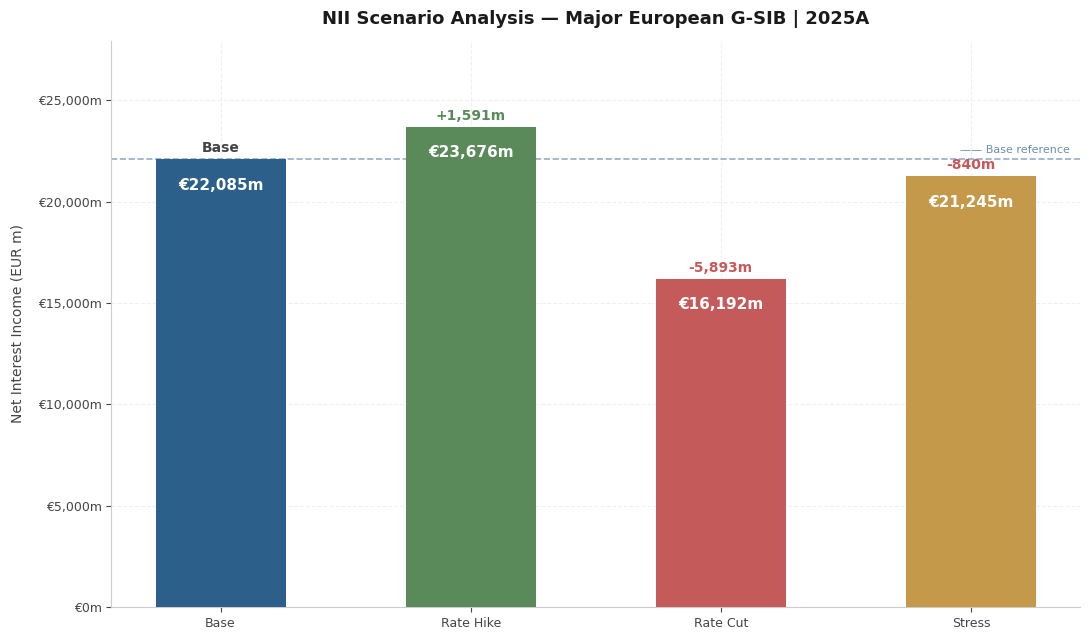

In [6]:
# --- Cell 7: NII Scenario Chart (Professional) ---

plt.style.use('default')
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Colour palette — professional muted
bar_colors = {
    "Base":      '#2c5f8a',
    "Rate Hike": '#5a8a5a',
    "Rate Cut":  '#c45a5a',
    "Stress":    '#c49a4a',
}
colors = [bar_colors[s] for s in results_df["Scenario"]]

# Bars
bars = ax.bar(results_df["Scenario"], results_df["NII"],
              color=colors, width=0.52, zorder=3, linewidth=0)

# Base NII reference line
ax.axhline(y=base_nii, color='#2c5f8a', linewidth=1.2,
           linestyle="--", alpha=0.5, zorder=2)

# NII value labels inside bars
for bar, val in zip(bars, results_df["NII"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 900,
            f"€{val:,.0f}m",
            ha="center", va="top",
            fontsize=11, fontweight="bold", color="white")

# Change vs Base labels above bars
for bar, chg in zip(bars, results_df["Change vs Base"]):
    sign = "+" if chg >= 0 else ""
    color = '#5a8a5a' if chg > 0 else '#c45a5a' if chg < 0 else '#444444'
    label = f"{sign}{chg:,.0f}m" if chg != 0 else "Base"
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            label,
            ha="center", va="bottom",
            fontsize=10, color=color, fontweight="bold")

ax.set_title('NII Scenario Analysis — Major European G-SIB | 2025A',
             fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)
ax.set_ylabel("Net Interest Income (EUR m)", fontsize=10, color='#444444', labelpad=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"€{x:,.0f}m"))
ax.tick_params(colors='#444444', labelsize=9)
ax.set_ylim(0, max(results_df["NII"]) * 1.18)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.grid(True, alpha=0.3, color='#cccccc', linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

ax.text(0.99, base_nii + 300, "—— Base reference",
        color='#2c5f8a', fontsize=8, alpha=0.7,
        ha="right", transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.show()

In [7]:
# --- Cell 8: Detailed Rate & Interest Breakdown ---

print("=" * 72)
print("  REPRICING DETAIL — New Rate per Item per Scenario")
print("=" * 72)

# Build a detailed breakdown for each scenario
for s in scenarios:
    shock = s["rate_shock"]
    beta  = s["deposit_beta"]
    shock_bp = int(shock * 10000)
    sign = "+" if shock_bp >= 0 else ""

    print(f"\n  {s['name'].upper()}  |  Shock: {sign}{shock_bp}bp  |  Deposit Beta: {beta}")
    print(f"  {'Item':<28} {'Balance':>10}  {'Base Rate':>9}  {'New Rate':>9}  {'Interest':>11}")
    print(f"  {'-'*28} {'-'*10}  {'-'*9}  {'-'*9}  {'-'*11}")

    total_inc = 0
    print(f"  {'ASSETS'}")
    for _, row in assets.iterrows():
        new_rate = row["base_rate"] + (shock * row["reprice_factor"])
        interest = row["balance"] * new_rate
        total_inc += interest
        print(f"  {row['item']:<28} {row['balance']:>10,.0f}  "
              f"{row['base_rate']:>8.2%}  {new_rate:>8.2%}  {interest:>11,.1f}")
    print(f"  {'Total Interest Income':<28} {'':>10}  {'':>9}  {'':>9}  {total_inc:>11,.1f}")

    total_exp = 0
    print(f"\n  {'LIABILITIES'}")
    for _, row in liabilities.iterrows():
        if row["uses_deposit_beta"]:
            new_rate = row["base_rate"] + (shock * beta)
        else:
            new_rate = row["base_rate"] + (shock * row["reprice_factor"])
        interest = row["balance"] * new_rate
        total_exp += interest
        print(f"  {row['item']:<28} {row['balance']:>10,.0f}  "
              f"{row['base_rate']:>8.2%}  {new_rate:>8.2%}  {interest:>11,.1f}")
    print(f"  {'Total Interest Expense':<28} {'':>10}  {'':>9}  {'':>9}  {total_exp:>11,.1f}")

    nii = total_inc - total_exp
    print(f"\n  {'★ NII':<28} {'':>10}  {'':>9}  {'':>9}  {nii:>11,.1f}")
    print(f"  {'─'*72}")

  REPRICING DETAIL — New Rate per Item per Scenario

  BASE  |  Shock: +0bp  |  Deposit Beta: 0.4
  Item                            Balance  Base Rate   New Rate     Interest
  ---------------------------- ----------  ---------  ---------  -----------
  ASSETS
  Cash & CB reserves              211,330     2.50%     2.50%      5,283.2
  Loans to customers              897,358     3.80%     3.80%     34,099.6
  Interbank loans                  26,259     3.10%     3.10%        814.0
  Securities portfolio            153,107     3.00%     3.00%      4,593.2
  Total Interest Income                                             44,790.1

  LIABILITIES
  Customer deposits             1,075,564     0.50%     0.50%      5,377.8
  Interbank funding                69,938     3.10%     3.10%      2,168.1
  Repo funding                    357,947     2.42%     2.42%      8,644.4
  Bonds issued                    173,933     3.25%     3.25%      5,652.8
  Subordinated debt                34,468     2

## Key Findings

| Scenario | NII (€m) | Change vs Base |
|---|---|---|
| Base (0bp) | 22,085 | — |
| Rate Hike (+200bp) | 23,676 | +1,591 |
| Rate Cut (−200bp) | 16,192 | −5,893 |
| Stress (+300bp) | 21,245 | −840 |

**Interpretation:**
- The Bank benefits moderately from rising rates (+€1.6bn at +200bp) due to a large floating-rate loan book repricing faster than retail deposits.
- The bank is highly exposed to falling rates: a −200bp cut would reduce NII by −€5.9bn (−27%), driven by rapid compression of asset yields while fixed-rate liabilities (bonds, sub debt) remain unchanged.
- Under extreme stress (+300bp), NII actually falls below Base (−€840m) because the large repo book (€358bn, fully floating) and higher deposit beta (0.60) together push liability costs above the gains on the asset side.
- The securities portfolio (€153bn) acts as a fixed-income anchor — it does not reprice under any scenario, providing NII stability but limiting upside.

**Limitations:**
- Static balance sheet — no volume growth modelled
- Deposit rate floor (0%) not applied — Rate Cut shows technically negative deposit rates
- Instantaneous parallel shock — no term structure or curve shape effects